In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer as knn

In [227]:
data_test=pd.read_csv(r"data\test.csv",sep=',')

data_test.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Alto K10 LXI CNG,Delhi,2014,40929,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN
1,Maruti Alto 800 2016-2019 LXI,Coimbatore,2013,54493,Petrol,Manual,Second,24.7 kmpl,796 CC,47.3 bhp,5.0,NaN
2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68 kmpl,2393 CC,147.8 bhp,7.0,25.27 Lakh
3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59 kmpl,1364 CC,null bhp,5.0,NaN
4,Hyundai i20 Magna,Mumbai,2014,29000,Petrol,Manual,First,18.5 kmpl,1197 CC,82.85 bhp,5.0,NaN


In [228]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

datat_train.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [236]:
# datat_train[datat_train.Name.str.startswith("Honda City 1.5 GXI")]

In [269]:
# datat_train[datat_train.Power.isna()]

In [238]:
print(datat_train.isna().sum())
print("\n",data_test.isna().sum())

Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64

 Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                 10
Power                  10
Seats                  11
New_Price            1052
dtype: int64


In [239]:
datat_train.describe()

,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,2013.358199,5.873838e+04,5.278735,9.479468
std,3.269742,9.126884e+04,0.808840,11.187917
min,1998.000000,1.710000e+02,0.000000,0.440000
25%,2011.000000,3.400000e+04,5.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,5.640000
75%,2016.000000,7.300000e+04,5.000000,9.950000
max,2019.000000,6.500000e+06,10.000000,160.000000


In [240]:
datat_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   str    
 1   Location           6019 non-null   str    
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   str    
 5   Transmission       6019 non-null   str    
 6   Owner_Type         6019 non-null   str    
 7   Mileage            6017 non-null   str    
 8   Engine             5983 non-null   str    
 9   Power              5983 non-null   str    
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    str    
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), str(9)
memory usage: 611.4 KB


In [241]:
datat_train.duplicated().sum()

np.int64(0)

In [242]:
print(f'consomation {datat_train['Mileage'].astype(str).str.split().str[-1].unique()}')
print(f'Engine {datat_train['Engine'].astype(str).str.split().str[-1].unique()}')
print (f'Power {datat_train['Power'].astype(str).str.split().str[-1].unique()}')

consomation ['km/kg' 'kmpl' nan]
Engine ['CC' nan]
Power ['bhp' nan]


In [243]:
pow=datat_train[datat_train['Power']=='null bhp'].index
datat_train.loc[pow, 'Power']=np.nan

In [244]:
Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    datat_train[col] = datat_train[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

In [245]:
datat_train.isna().sum()

Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                 143
Seats                  42
New_Price            5195
Price                   0
dtype: int64

In [246]:
imputer = knn(n_neighbors=10)
datat_train['Power']=imputer.fit_transform(datat_train[['Power']])
datat_train['Engine']=imputer.fit_transform(datat_train[['Engine']])
datat_train['Seats']=imputer.fit_transform(datat_train[['Seats']])


In [290]:
datat_train[datat_train.Name.str.startswith("Honda City 1.5 GXI")]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,0.0,1621.27645,113.25305,5.278735,NaN,2.95
1385,Honda City 1.5 GXI,Pune,2004,115000,Petrol,Manual,Second,0.0,1621.27645,113.25305,5.278735,NaN,1.50
3305,Honda City 1.5 GXI,Jaipur,2007,75055,Petrol,Manual,First,12.8,1493.00000,100.00000,5.000000,NaN,2.30
4767,Honda City 1.5 GXI,Mumbai,2005,81000,Petrol,Manual,Second,12.8,1493.00000,100.00000,5.000000,NaN,1.10
5270,Honda City 1.5 GXI,Bangalore,2002,53000,Petrol,Manual,Second,0.0,1621.27645,113.25305,5.278735,NaN,1.85


In [291]:
datat_train.isna().sum()

Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                  0
Power                   0
Seats                   0
New_Price            5195
Price                   0
dtype: int64

In [292]:
data_clean=datat_train.drop(columns=('New_Price'))

In [293]:
data_clean.dropna(inplace=True)

In [294]:
data_clean.isna().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [295]:
data_clean['Name'].unique()


<StringArray>
[                    'Maruti Wagon R LXI CNG',
           'Hyundai Creta 1.6 CRDi SX Option',
                               'Honda Jazz V',
                          'Maruti Ertiga VDI',
            'Audi A4 New 2.0 TDI Multitronic',
            'Hyundai EON LPG Era Plus Option',
                     'Nissan Micra Diesel XV',
          'Toyota Innova Crysta 2.8 GX AT 8S',
        'Volkswagen Vento Diesel Comfortline',
             'Tata Indica Vista Quadrajet LS',
 ...
        'Skoda Rapid Ultima 1.6 TDI Elegance',
          'Mercedes-Benz GLA Class 200 Sport',
                            'Tata Indica LEI',
                'Hyundai i20 2015-2017 Magna',
           'Tata New Safari DICOR 2.2 VX 4x2',
                         'Hyundai Elantra SX',
                     'Maruti Wagon R Duo Lxi',
 'Volkswagen Polo IPL II 1.2 Petrol Highline',
                      'Tata Bolt Revotron XT',
                      'Mahindra Xylo D4 BSIV']
Length: 1874, dtype: str

In [296]:
data_clean['Name']

0                 Maruti Wagon R LXI CNG
1       Hyundai Creta 1.6 CRDi SX Option
2                           Honda Jazz V
3                      Maruti Ertiga VDI
4        Audi A4 New 2.0 TDI Multitronic
                      ...               
6014                    Maruti Swift VDI
6015            Hyundai Xcent 1.1 CRDi S
6016               Mahindra Xylo D4 BSIV
6017                  Maruti Wagon R VXI
6018               Chevrolet Beat Diesel
Name: Name, Length: 6017, dtype: str

In [297]:
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean.drop(columns=['Name'], inplace=True)
data_clean


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,Maruti,Wagon R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda,Jazz V
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,Ertiga VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,A4 New 2.0 TDI Multitronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,4.75,Maruti,Swift VDI
6015,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,4.00,Hyundai,Xcent 1.1 CRDi S
6016,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112.00,8.0,2.90,Mahindra,Xylo D4 BSIV
6017,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.10,5.0,2.65,Maruti,Wagon R VXI


In [254]:
data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

In [255]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 6017 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6017 non-null   str    
 1   Year               6017 non-null   int64  
 2   Kilometers_Driven  6017 non-null   int64  
 3   Fuel_Type          6017 non-null   str    
 4   Transmission       6017 non-null   str    
 5   Owner_Type         6017 non-null   str    
 6   Mileage            6017 non-null   float64
 7   Engine             6017 non-null   int64  
 8   Power              6017 non-null   float64
 9   Seats              6017 non-null   int64  
 10  Price              6017 non-null   float64
 11  Brand              6017 non-null   str    
 12  Model              6017 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 658.1 KB


In [256]:
data_clean.rename(columns=({'Mileage': 'Consommation'}), inplace=True)

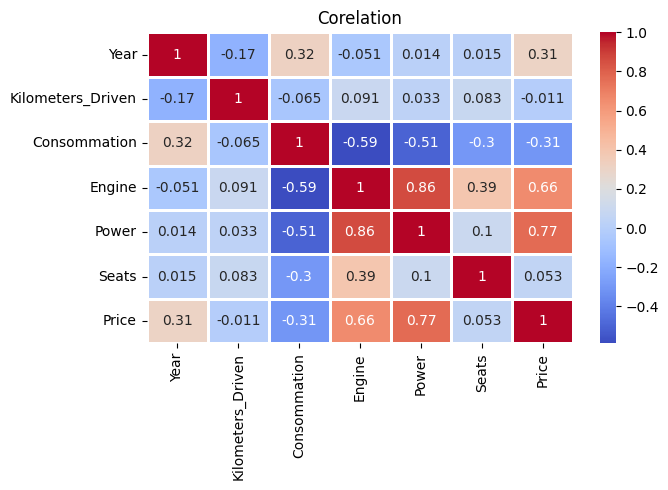

In [257]:
cor = data_clean.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

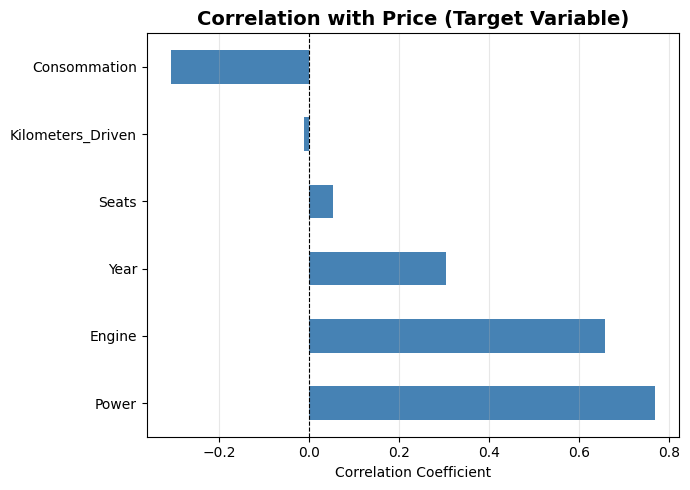

In [258]:
target_corr = cor['Price'].sort_values(ascending=False)

# Visualize
plt.figure(figsize=(7, 5))
target_corr[target_corr.index != 'Price'].plot(kind='barh', color='steelblue')
plt.title('Correlation with Price (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

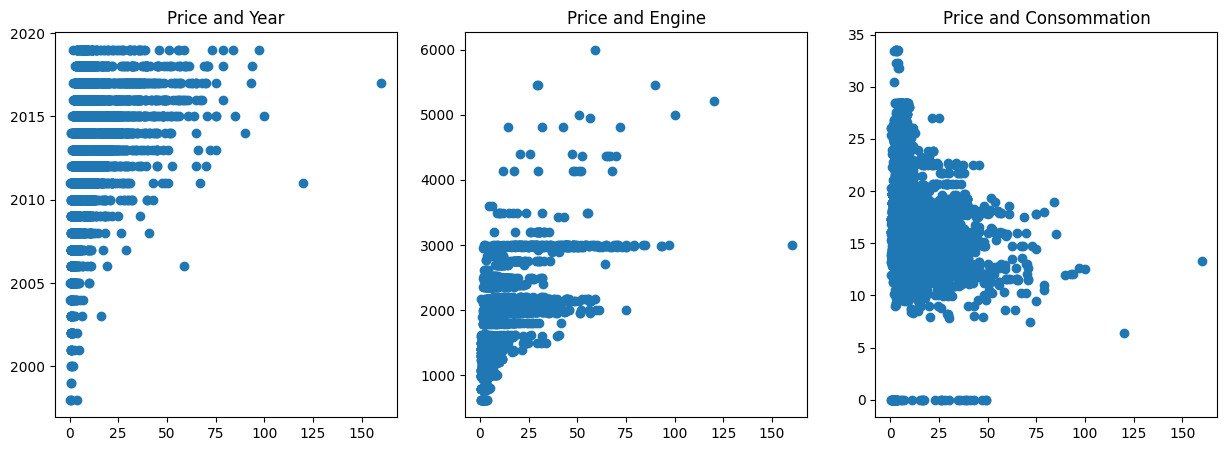

In [259]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(15,5))
ax1.scatter(data_clean['Price'],data_clean['Year'])
ax2.scatter(data_clean['Price'],data_clean['Engine'])
ax3.scatter(data_clean['Price'],data_clean['Consommation'])

ax1.set_title('Price and Year')
ax2.set_title('Price and Engine')
ax3.set_title('Price and Consommation')

plt.show()




In [274]:
data_clean.Fuel_Type.unique()

<StringArray>
['CNG', 'Diesel', 'Petrol', 'LPG']
Length: 4, dtype: str

In [276]:
data_clean[data_clean.Price > 100]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Consommation,Engine,Power,Seats,Price,Brand,Model
4079,Hyderabad,2017,25000,Diesel,Automatic,First,13.33,2993,255.0,5,160.0,Land,Rover Range Rover 3.0 Diesel LWB Vogue
5781,Delhi,2011,6500,Petrol,Automatic,Third,6.40,5204,560.0,2,120.0,Lamborghini,Gallardo Coupe


In [261]:
data_clean['Transmission'].value_counts()


Transmission
Manual       4299
Automatic    1718
Name: count, dtype: int64

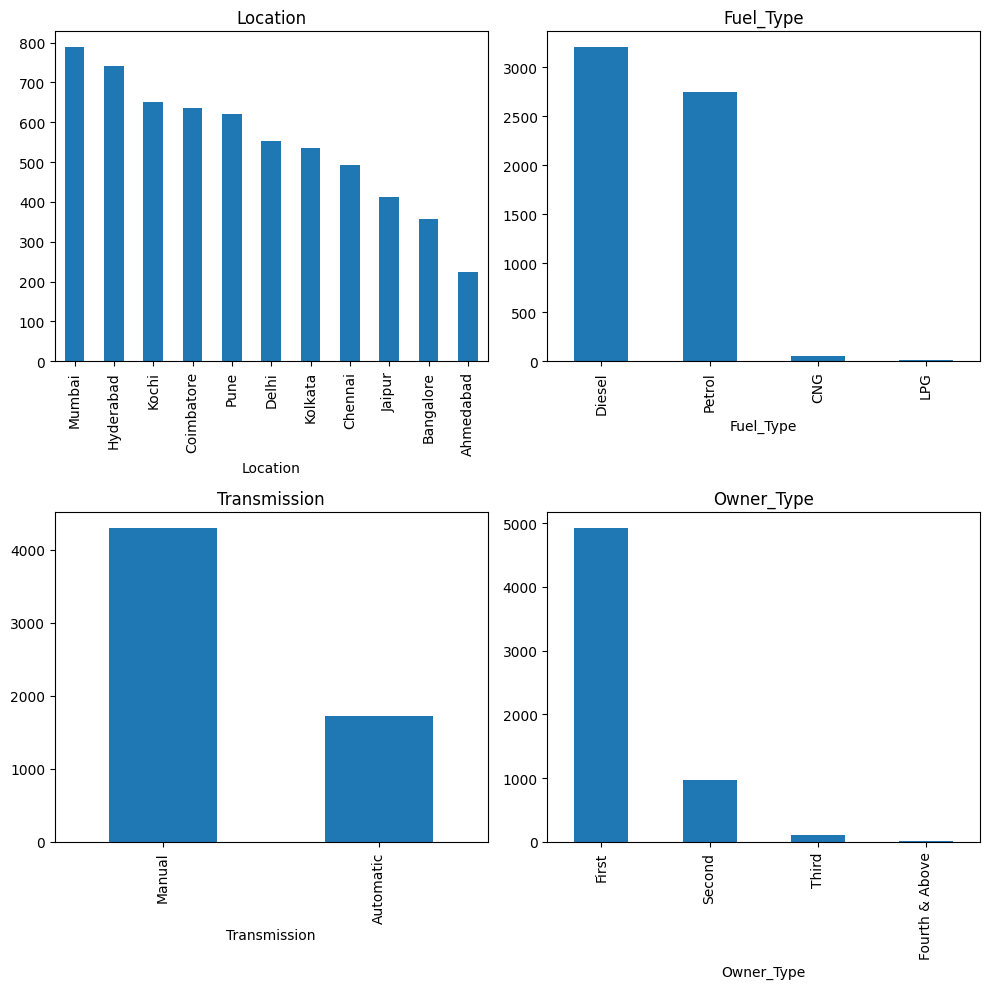

In [262]:
fig, axes1 = plt.subplots(2,2, figsize=(10,10))
data_clean['Location'].value_counts().plot(kind='bar', ax=axes1[0,0], title='Location')
data_clean['Fuel_Type'].value_counts().plot(kind='bar', ax=axes1[0,1], title='Fuel_Type')
data_clean['Transmission'].value_counts().plot(kind='bar', ax=axes1[1,0], title='Transmission')
data_clean['Owner_Type'].value_counts().plot(kind='bar', ax=axes1[1,1], title='Owner_Type')
plt.tight_layout()
plt.show()

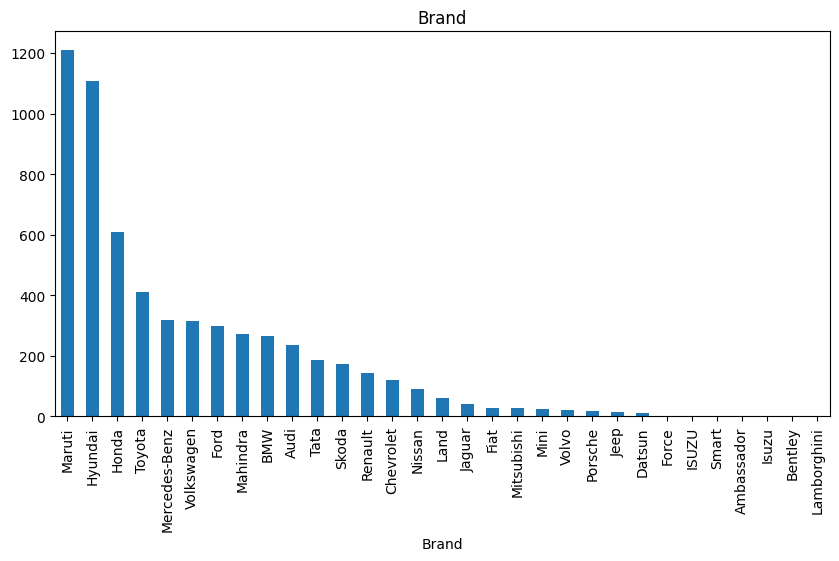

In [263]:
fig, ax = plt.subplots(figsize=(10, 5))
data_clean['Brand'].value_counts().plot(kind='bar', ax=ax, title='Brand')
plt.show()

In [264]:
brand_counts = data_clean['Brand'].value_counts()

# 2. Identify brands that appear less than 5 times
rare_brands = brand_counts[brand_counts < 5].index

data_clean.drop(rare_brands)

KeyError: "['Force', 'ISUZU', 'Smart', 'Ambassador', 'Isuzu', 'Bentley', 'Lamborghini'] not found in axis"

In [ ]:
data_clean

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Consommation,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Delhi,2014,27365,Diesel,Manual,First,28.40,1248,74.00,5,4.75,Maruti,Swift VDI
6015,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120,71.00,5,4.00,Hyundai,Xcent 1.1 CRDi S
6016,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498,112.00,8,2.90,Mahindra,Xylo D4 BSIV
6017,Kolkata,2013,46000,Petrol,Manual,First,18.90,998,67.10,5,2.65,Maruti,Wagon R VXI


In [283]:
data_clean[data_clean.Model.str.startswith("XUV500 W8 2WD")]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Consommation,Engine,Power,Seats,Price,Brand,Model
94,Delhi,2014,58000,Diesel,Manual,First,15.1,2179,140.0,7,8.10,Mahindra,XUV500 W8 2WD
108,Delhi,2012,65000,Diesel,Manual,Second,16.0,2179,140.0,7,5.75,Mahindra,XUV500 W8 2WD
163,Mumbai,2012,32792,Diesel,Manual,First,15.1,2179,140.0,7,7.90,Mahindra,XUV500 W8 2WD
449,Kochi,2013,61672,Diesel,Manual,First,16.0,2179,140.0,7,7.53,Mahindra,XUV500 W8 2WD
649,Delhi,2012,72450,Diesel,Manual,First,15.1,2179,140.0,7,8.10,Mahindra,XUV500 W8 2WD
754,Ahmedabad,2015,72007,Diesel,Manual,First,15.1,2179,140.0,7,9.90,Mahindra,XUV500 W8 2WD
881,Delhi,2011,66000,Diesel,Manual,First,15.1,2179,140.0,7,5.50,Mahindra,XUV500 W8 2WD
1257,Kolkata,2013,43000,Diesel,Manual,First,16.0,2179,140.0,7,7.00,Mahindra,XUV500 W8 2WD
1435,Mumbai,2012,37000,Diesel,Manual,First,16.0,2179,140.0,7,7.75,Mahindra,XUV500 W8 2WD
1493,Delhi,2012,75000,Diesel,Manual,Second,15.1,2179,140.0,7,6.25,Mahindra,XUV500 W8 2WD
